## Data Loading & Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
emp_dat = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
emp_dat.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
emp_dat.info()
# 1470 rows, 35 columns
# 26 numeric 9 categorical

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
attrition_rate = (emp_dat["Attrition"]=="Yes").mean() * 100
print(f"The attrition rate is {attrition_rate:.2f}%")

The attrition rate is 16.12%


**Note**: Based on the attrition rate we can clearly observe that the dataset is imbalenced, which means it is biased for the employees who stay. 83.88% of the data consists of people who stayed, this completely useless model would be 83.88% accurate.

In [5]:
# Rows with any column empty
emp_dat[emp_dat.isna().any(axis=1)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [6]:
# Checking for duplicated rows
emp_dat.duplicated().sum()

np.int64(0)

In [7]:
# The columns with constant value
emp_dat.columns[emp_dat.nunique()==1].to_list()

['EmployeeCount', 'Over18', 'StandardHours']

In [8]:
# Removing the unwanted columns
emp_dat_filt=emp_dat.drop(["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], axis=1)
emp_dat_filt

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


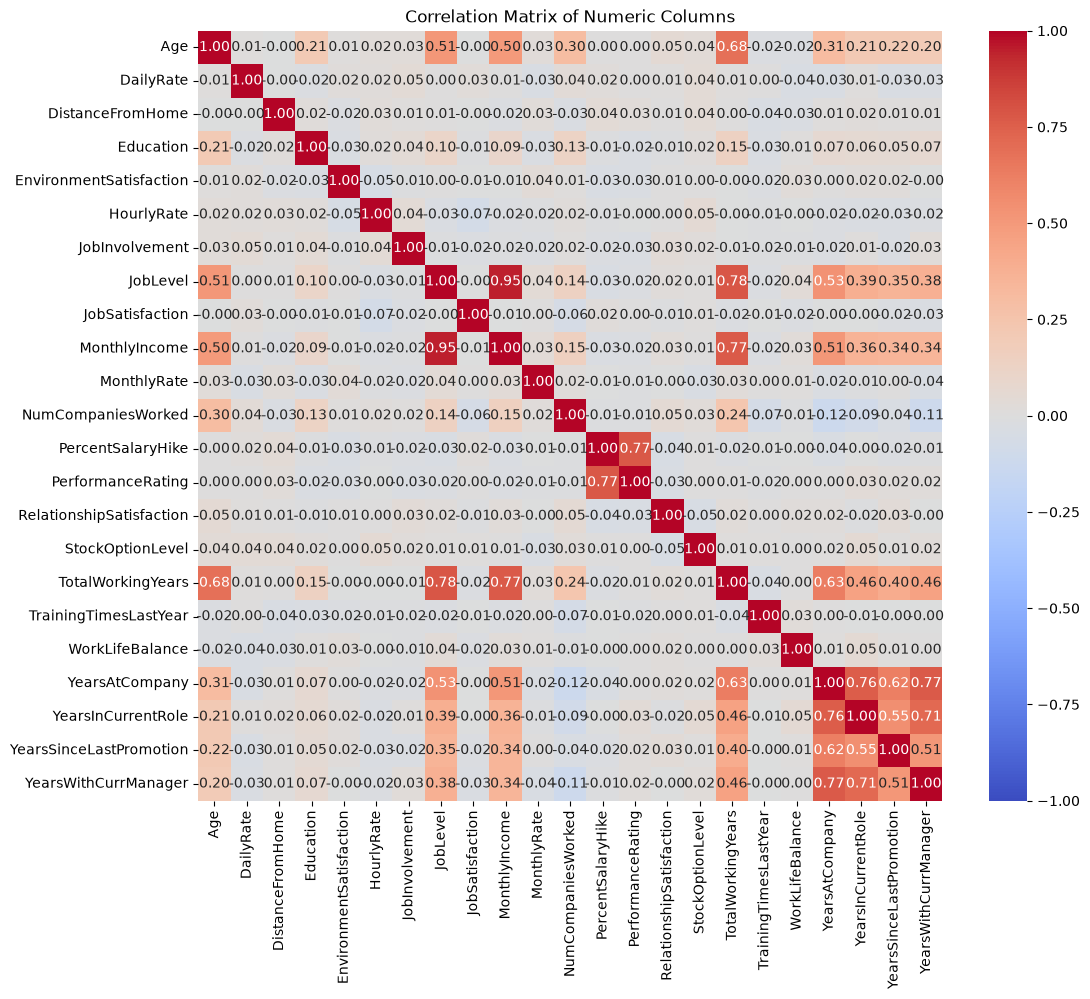

In [9]:
# Correlation matrix of numeric columns
numeric_cols = emp_dat_filt.select_dtypes(include=[np.number]).columns
corr_matrix = emp_dat_filt[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Columns") 
plt.show()

In [10]:
to_drop = ["JobLevel", "PerformanceRating", "YearsWithCurrManager", "YearsInCurrentRole"]
emp_dat_filt = emp_dat_filt.drop(to_drop, axis=1)

In [11]:
# One hot encoding the categorical columns
categories = emp_dat_filt.select_dtypes(include=['object','str']).columns
encoded_dat = pd.get_dummies(emp_dat_filt, columns=categories, drop_first=True, dtype=np.int8)
encoded_dat.head(10)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,MonthlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,4,5993,19479,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,5130,24907,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,92,2,3,2090,2396,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,4,56,3,3,2909,23159,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,1,40,3,2,3468,16632,...,1,0,0,0,0,0,0,1,0,0
5,32,1005,2,2,4,79,3,4,3068,11864,...,1,0,0,0,0,0,0,0,1,0
6,59,1324,3,3,3,81,4,1,2670,9964,...,1,0,0,0,0,0,0,1,0,1
7,30,1358,24,1,4,67,3,3,2693,13335,...,1,0,0,0,0,0,0,0,0,0
8,38,216,23,3,4,44,2,3,9526,8787,...,0,0,1,0,0,0,0,0,1,0
9,36,1299,27,3,3,94,3,3,5237,16577,...,0,0,0,0,0,0,0,1,0,0


In [12]:
encoded_dat = encoded_dat.rename(columns={'Attrition_Yes': 'Attrition'})
new_order = ["Attrition"] + [col for col in encoded_dat.columns if col!="Attrition"]
encoded_dat = encoded_dat[new_order]
encoded_dat

,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,1,41,1102,1,2,2,94,3,4,5993,...,0,0,0,0,0,1,0,0,1,1
1,0,49,279,8,1,3,61,2,2,5130,...,0,0,0,0,1,0,0,1,0,0
2,1,37,1373,2,2,4,92,2,3,2090,...,1,0,0,0,0,0,0,0,1,1
3,0,33,1392,3,4,4,56,3,3,2909,...,0,0,0,0,1,0,0,1,0,1
4,0,27,591,2,1,1,40,3,2,3468,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0,36,884,23,2,3,41,4,4,2571,...,1,0,0,0,0,0,0,1,0,0
1466,0,39,613,6,1,4,42,2,1,9991,...,0,0,0,0,0,0,0,1,0,0
1467,0,27,155,4,3,2,87,4,2,6142,...,0,0,1,0,0,0,0,1,0,1
1468,0,49,1023,2,3,4,63,2,2,5390,...,0,0,0,0,0,1,0,1,0,0


## EDA

In [13]:
# Attrition vs Department
department_data = (emp_dat_filt.groupby(["Department"])["Attrition"]
                    .apply(lambda x: ((x=="Yes").mean() * 100).__round__(2))
                    .sort_values(ascending=False)
                    .reset_index(name="Attrition_Rate(%)"))
department_data

,Department,Attrition_Rate(%)
0,Sales,20.63
1,Human Resources,19.05
2,Research & Development,13.84


In [14]:
# Attrition vs Job Role
job_role_data = (emp_dat_filt.groupby(["JobRole"])["Attrition"]
                .apply(lambda x: (x=="Yes").mean() * 100)
                .sort_values(ascending=False)
                .reset_index(name="Attrition_Rate(%)"))
job_role_data

,JobRole,Attrition_Rate(%)
0,Sales Representative,39.759036
1,Laboratory Technician,23.938224
2,Human Resources,23.076923
3,Sales Executive,17.484663
4,Research Scientist,16.095890
5,Manufacturing Director,6.896552
6,Healthcare Representative,6.870229
7,Manager,4.901961
8,Research Director,2.500000


findfont: Failed to find font weight medium, now using 400.


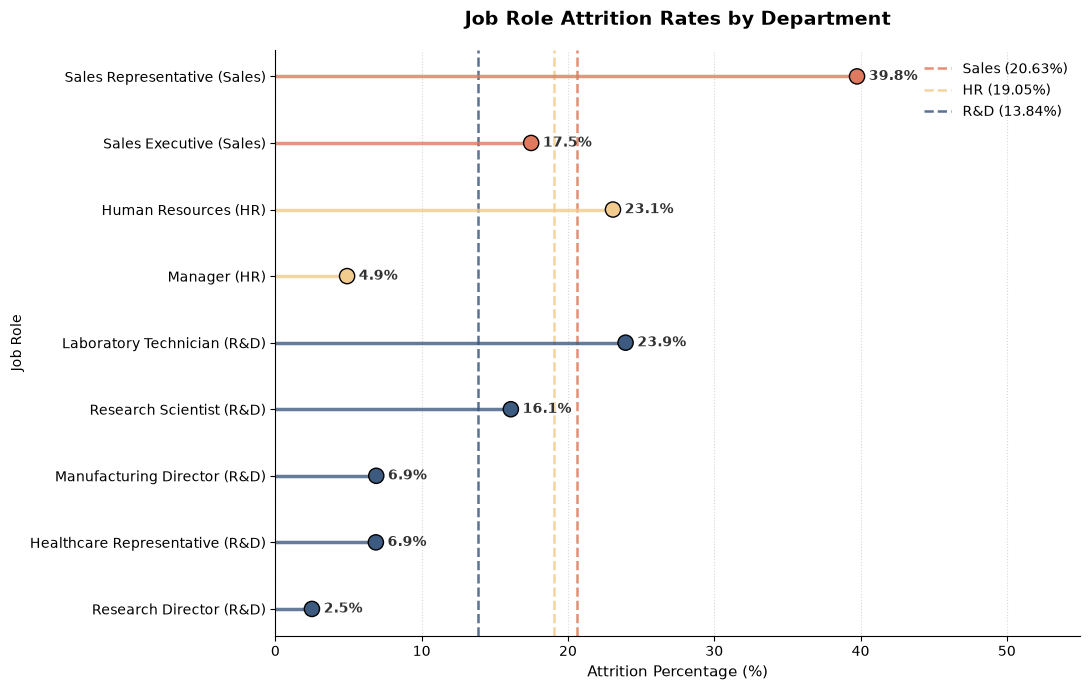

In [15]:
# Job-role data with department mapping
job_role_data['Department'] = [
        'Sales', 'Research & Development', 'Human Resources',
        'Sales', 'Research & Development', 'Research & Development',
        'Research & Development', 'Human Resources', 'Research & Development']

df_dept = pd.DataFrame(department_data)
df_role = pd.DataFrame(job_role_data)
df_dept = df_dept.rename(columns={'Attrition_Rate(%)': 'Dept_Rate'})
df_role = df_role.rename(columns={'Attrition_Rate(%)': 'Role_Rate'})

# Merge role rates with department benchmark rates
df = pd.merge(df_role, df_dept, on='Department')
df = df.sort_values(by=['Dept_Rate', 'Role_Rate'], ascending=[True, True]).reset_index(drop=True)

# Department colors
dept_colors = {
    'Sales': '#e07a5f',
    'Human Resources': '#f2cc8f',
    'Research & Development': '#3d5a80'
}
df['Color'] = df['Department'].map(dept_colors)

# Display labels for departments
dept_labels = {
    'Human Resources': 'HR',
    'Research & Development': 'R&D'
}

# Create plot
fig, ax = plt.subplots(figsize=(11, 7))

# Vertical dashed lines for department attrition rates
for dept, row in df_dept.set_index('Department').iterrows():
    ax.axvline(
        x=row['Dept_Rate'],
        color=dept_colors[dept],
        linestyle='--',
        linewidth=1.8,
        alpha=0.85,
        label=f"{dept_labels.get(dept, dept)} ({row['Dept_Rate']:.2f}%)"
    )

# Horizontal lollipop stems and markers
ax.hlines(y=df.index, xmin=0, xmax=df['Role_Rate'],
          color=df['Color'], linewidth=2.5, alpha=0.8)
ax.scatter(df['Role_Rate'], df.index, color=df['Color'],
           s=120, edgecolor='black', zorder=3)

# Y-axis labels
y_labels = [f"{row['JobRole']} ({dept_labels.get(row['Department'], row['Department'])})"
            for _, row in df.iterrows()]
ax.set_yticks(df.index)
ax.set_yticklabels(y_labels, fontsize=10, fontweight='medium')

# Value labels at the end of each lollipop
for idx, row in df.iterrows():
    ax.text(row['Role_Rate'] + 0.8, idx, f"{row['Role_Rate']:.1f}%",
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

# Formatting
ax.set_title('Job Role Attrition Rates by Department', fontsize=14, fontweight='bold', pad=18)
ax.set_xlabel('Attrition Percentage (%)', fontsize=11)
ax.set_ylabel('Job Role')
ax.set_xlim(0, max(df['Role_Rate'].max(), df_dept['Dept_Rate'].max()) + 5)
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend for department benchmark lines
ax.legend(loc='upper right', frameon=False)

plt.xlim(0,55)
plt.tight_layout()
plt.show()


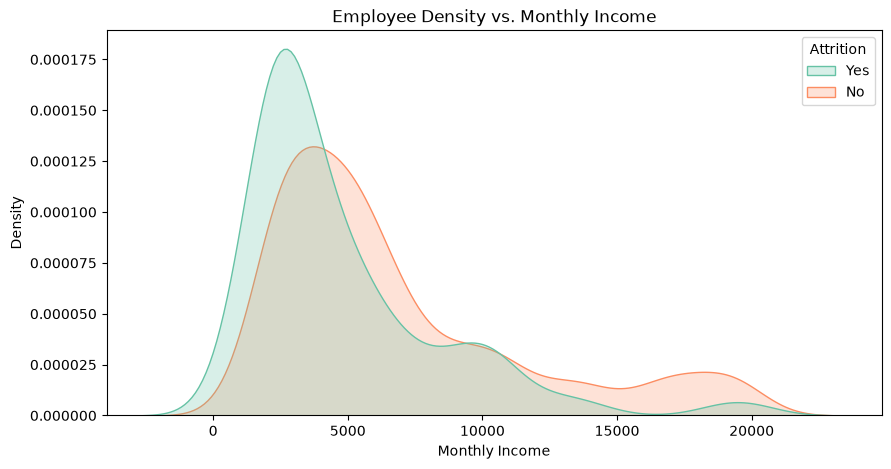

In [16]:
# Attrition vs Monthly Income
# Continuous KDE plot grouped by attrition
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=emp_dat_filt,
    x="MonthlyIncome",
    hue="Attrition",
    common_norm=False,
    fill=True,
    palette="Set2"
)
plt.title("Employee Density vs. Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Density")
plt.show()

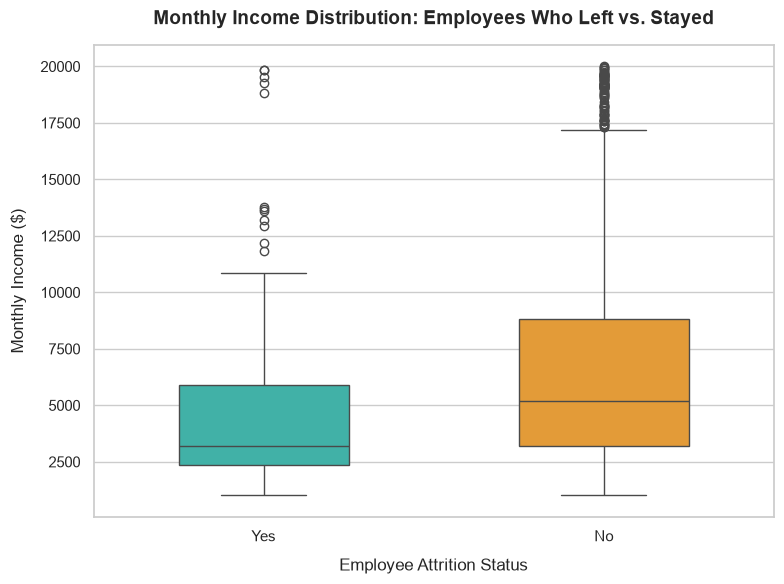

In [17]:
# Box plot comparing Monthly Income across Attrition status
# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create the figure container
plt.figure(figsize=(8, 6))

# Generate the box plot comparing Monthly Income across Attrition status
sns.boxplot(
    data=emp_dat_filt,
    x="Attrition",
    y="MonthlyIncome",
    order=["Yes", "No"],
    palette={"Yes": "#2ec4b6", "No": "#ff9f1c"},
    hue="Attrition",
    width=0.5,
)

# Add clear, descriptive labels and titles
plt.title(
    "Monthly Income Distribution: Employees Who Left vs. Stayed",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Employee Attrition Status", fontsize=12, labelpad=10)
plt.ylabel("Monthly Income ($)", fontsize=12, labelpad=10)

# Display the plot cleanly
plt.tight_layout()
plt.show()

In [18]:
# Attrition vs Work-Life Balance rating
(emp_dat_filt.groupby(["WorkLifeBalance"])["Attrition"]
 .apply(lambda x: (x=="Yes").mean() * 100)
 .sort_values(ascending=False))
# Bad work life have the highest attrition rate

WorkLifeBalance
1    31.250000
4    17.647059
2    16.860465
3    14.221725
Name: Attrition, dtype: float64

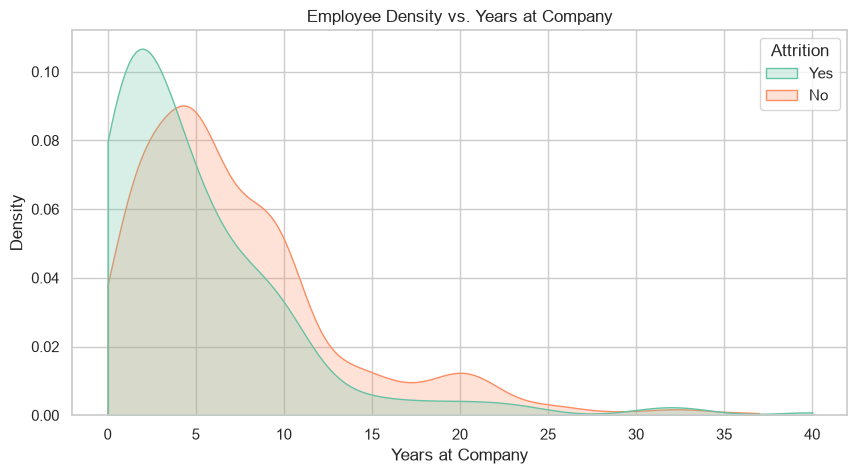

In [19]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=emp_dat_filt,
    x="YearsAtCompany",
    hue="Attrition",
    common_norm=False,
    fill=True,
    palette="Set2",
    cut=0
)
plt.title("Employee Density vs. Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Density")
plt.show()

**Insights**
- Sales department have highest attrition rate of 20.63%

- The top 3 roles having high attrition rate is Sales Representative(39.75%), Laboratory Technician(23.93%), Human Resources(23.07%)

- Employees with mothly income less than 5000 tend to leave more.

- Employees with bad work life leave more with the rate of 31.25%

- Between 0 and 5 years, a new hire is statistically more likely to be in the "leaving" camp than the "staying" camp compared to the rest of the company.

- Right around 5 to 40 years, the lines cross. The red line stays higher for the rest of the timeline, proving that as time goes on, the probability shifts heavily toward staying.

## Model Building

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Isolate your target and numeric features
X = encoded_dat.drop(columns=['Attrition'])
y = encoded_dat['Attrition']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X.select_dtypes(include=['int64']).columns
# Removing the ordinal columns from scaling as they are already encoded in a meaningful way
numeric_cols = numeric_cols.drop(["Education", "EnvironmentSatisfaction", "JobInvolvement",
                                   "JobSatisfaction", "RelationshipSatisfaction", "StockOptionLevel", "WorkLifeBalance"])

# Initialize and apply StandardScaler only on numeric columns
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cols)],
    remainder='passthrough' # Leaving the one-hot encoded columns completely alone
)
preprocessor.set_output(transform="pandas")

# Fit on training data AND transform it
X_train_scaled = preprocessor.fit_transform(X_train)

# Transform testing data using the training data's mean and variance
X_test_scaled = preprocessor.transform(X_test)


In [21]:
from imblearn.over_sampling import SMOTE
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE only on the scaled training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Original dataset:", y_train.value_counts().to_dict())
print("Resampled dataset:", y_train_balanced.value_counts().to_dict())

Original dataset: {0: 978, 1: 198}
Resampled dataset: {0: 978, 1: 978}


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# --- Preparation for Logestic Regression (Needs SMOTE) ---
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train_balanced, y_train_balanced)

y_pred1 = model1.predict(X_test_scaled)
y_prob1 = model1.predict_proba(X_test_scaled)[:, 1] # Probability of Attrition == 1
roc_auc1 = roc_auc_score(y_test, y_prob1)
print("Evaluation Metrics for Logistic Regression:")
dat1 = classification_report(y_test, y_pred1, output_dict=True)
print(pd.DataFrame(dat1).T.round(2))
print(f"ROC-AUC Score: {roc_auc1:.4f}")

Evaluation Metrics for Logistic Regression:
              precision  recall  f1-score  support
0                  0.93    0.92      0.92   255.00
1                  0.50    0.51      0.51    39.00
accuracy           0.87    0.87      0.87     0.87
macro avg          0.71    0.72      0.71   294.00
weighted avg       0.87    0.87      0.87   294.00
ROC-AUC Score: 0.7956


In [23]:
# --- Preparation for Trees (Uses original scaled data + weight parameters) ---
model2 = RandomForestClassifier(class_weight='balanced', random_state=42)
model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)
y_prob2 = model2.predict_proba(X_test_scaled)[:, 1] # Probability of Attrition == 1
roc_auc2 = roc_auc_score(y_test, y_prob2)
print("Evaluation Metrics for Random Forest:")
dat2 = classification_report(y_test, y_pred2, output_dict=True)
print(pd.DataFrame(dat2).T.round(2))
print(f"ROC-AUC Score: {roc_auc2:.4f}")


Evaluation Metrics for Random Forest:
              precision  recall  f1-score  support
0                  0.90    0.98      0.93   255.00
1                  0.62    0.26      0.36    39.00
accuracy           0.88    0.88      0.88     0.88
macro avg          0.76    0.62      0.65   294.00
weighted avg       0.86    0.88      0.86   294.00
ROC-AUC Score: 0.7663


In [24]:
# --- Preparation for Gradient Boosting (Uses original scaled data + sample weights) ---
# GradientBoosting doesn't have a 'class_weight' param, so we calculate sample weights manually
model3 = GradientBoostingClassifier(random_state=42)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model3.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred3 = model3.predict(X_test_scaled)
y_prob3 = model3.predict_proba(X_test_scaled)[:, 1] # Probability of Attrition == 1
roc_auc3 = roc_auc_score(y_test, y_prob3)
print("Evaluation Metrics for Gradient Boosting:")
dat3 = classification_report(y_test, y_pred3, output_dict=True)
print(pd.DataFrame(dat3).T.round(2))
print(f"ROC-AUC Score: {roc_auc3:.4f}")

Evaluation Metrics for Gradient Boosting:
              precision  recall  f1-score  support
0                  0.93    0.87      0.90   255.00
1                  0.40    0.56      0.47    39.00
accuracy           0.83    0.83      0.83     0.83
macro avg          0.66    0.72      0.68   294.00
weighted avg       0.86    0.83      0.84   294.00
ROC-AUC Score: 0.7539


## Comparision

In [25]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': [],
    'Overall Accuracy': []
}
for i, (d, auc) in enumerate(zip([dat1, dat2, dat3], [roc_auc1, roc_auc2, roc_auc3])):
    results['Precision'].append(d['1']['precision'].__round__(2))
    results['Recall'].append(d['1']['recall'].__round__(2))
    results['F1-Score'].append(d['1']['f1-score'].__round__(2))
    results['ROC-AUC'].append(auc.__round__(4))
    results['Overall Accuracy'].append(d['accuracy'].__round__(2))
print(pd.DataFrame(results).to_string(index=False))

              Model  Precision  Recall  F1-Score  ROC-AUC  Overall Accuracy
Logistic Regression       0.50    0.51      0.51   0.7956              0.87
      Random Forest       0.62    0.26      0.36   0.7663              0.88
  Gradient Boosting       0.40    0.56      0.47   0.7539              0.83


In heavily imbalanced datasets, overall accuracy is highly misleading. The minority class F1-Score is the most reliable metric.

Since the **Logestic Regression** model has the highest RAC-AUC score and F1 score, it the best overall model.

**Why did this happen?**
In HR data, the relationships are often relatively "linear" (e.g., as Distance from Home increases, Attrition risk increases). Tree-based models (RF and Gradient Boosting) often require more hyperparameter tuning to beat a well-scaled Logistic Regression on a smaller dataset like this one.

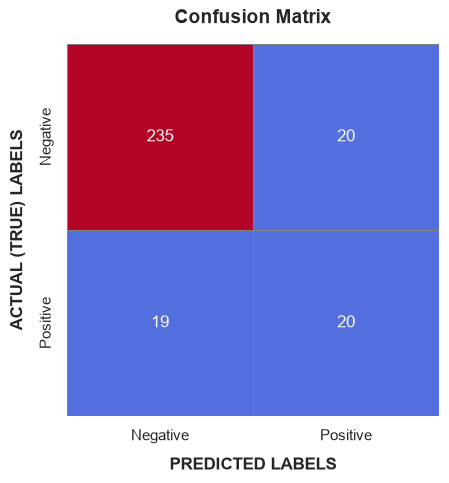

In [26]:
# Confusion Matrix heatmap for the best model (Logistic Regression)
cm = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False,
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'], vmin=0, vmax=cm.max(), linewidths=0.5, linecolor='gray', square=True)

# Clear and prominent axis labels
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('PREDICTED LABELS', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('ACTUAL (TRUE) LABELS', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

In [27]:
coefficients = model1.coef_[0]

# Get the feature names in the exact order they came out of the preprocessor
feature_names = X_train_scaled.columns

# Create a clean DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute importance to see what matters most overall
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False).head(11)

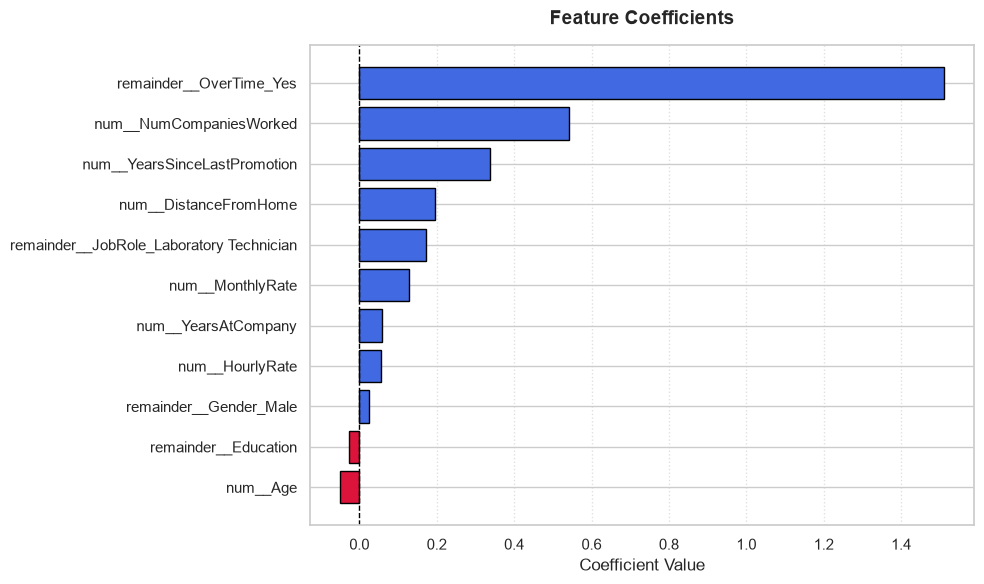

In [28]:
df = pd.DataFrame(feature_importance).iloc[::-1].reset_index(drop=True)

# Define distinct colors for positive and negative values
colors = ['crimson' if x < 0 else 'royalblue' for x in df['Coefficient']]

# Plotting configuration
plt.figure(figsize=(10, 6))
bars = plt.barh(df['Feature'], df['Coefficient'], color=colors, edgecolor='black')

# Add visual midline and text labels for values
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Coefficients', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

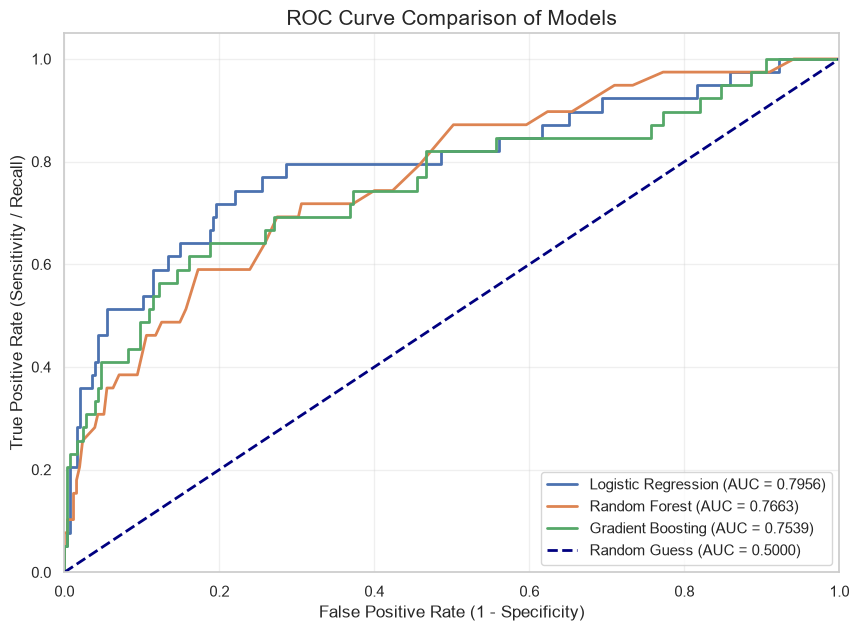

In [29]:
# ROC curve comparing all three models
from sklearn.metrics import roc_curve, auc

models = [
    {'label': 'Logistic Regression', 'model': model1, 'y_prob': y_prob1},
    {'label': 'Random Forest', 'model': model2, 'y_prob': y_prob2},
    {'label': 'Gradient Boosting', 'model': model3, 'y_prob': y_prob3}
]
plt.figure(figsize=(10, 7))

for m in models:
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(y_test, m['y_prob'])
    
    # Calculate Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve
    plt.plot(fpr, tpr, label=f"{m['label']} (AUC = {roc_auc:.4f})", lw=2)

# Plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve Comparison of Models', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


- The top 3 factors which predict that employee will leave are Over time, Number of Companies worked and Years since last promotion.
- HR should prioritize the Sales Representative role due to its critical 39.8% attrition rate, and focus department-wide retention efforts on Sales which has the highest overall turnover at 20.63%.
- Working overtime is the strongest driving factor of attrition by a wide margin, while compensation factors like monthly and hourly rates have a minimal, weak impact.
  - Implement an Overtime Cap Policy: Restrict weekly overtime hours specifically for Sales Representatives and Laboratory Technicians to prevent burnout from the leading driver of attrition.
  - Launch Targeted Stay Interviews: Mandate HR to conduct immediate retention conversations with any Sales employee who has passed their two-year promotion window or has a long commute.
- Important Considerations for HR
  - Because of the low recall of 0.51, the model is effectively missing nearly 50% of the employees who are actually going to leave.
  - Reducing overtime might not automatically stop someone from leaving if the real reason is a toxic manager (which might not be fully captured in the data).
  - If your company historically had a culture where certain demographics (like a specific Age group or Gender) left more often due to lack of inclusion, the model will "learn" that these groups are inherently high-risk.
  - Logistic Regression assumes a "straight line" relationship. The model might miss "extreme" cases where the relationship isn't a simple straight line.
  - Finally use the model just as a risk signal.
